<a href="https://colab.research.google.com/github/Murcha1990/ML_AI25/blob/main/Hometasks/Base/HW1_Regression_with_inference_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание №1 (base). Часть 1**

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;

**Максимальная оценка за дз**
> Оценка за первую часть домашки = $min(\text{ваш балл}, 7)$


**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.**

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

random.seed(42)
np.random.seed(42)

Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

**Ответ Задание 0 (0 баллов).**

Фиксация сидов необходима для воспроизводимости результатов.

Если сид не зафиксировать, случайное разбиение данных на `train/test`, например, или случайная инициализация весов могут привести к другим результатам без внесения явных изменений. Или наоборот, привести к видимости отсутствия изменений, несмотря на их наличие в действительности.



# **Часть 1 | EDA и визуализация**

Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков (2.5 балла)
- Визуализации признаков и их анализ (1 балл)

Всего можно набрать 3.5 основных балла и 0.65 бонусных. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (2.5 балла)**

In [2]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1 (0.5 балла)**

Вы уже встречались с pandas в первой половине семестра. Теперь будем постоянно (кроме некоторых случаев) использовать его для анализа данных и наслаивать навыки. Выполните операции, направленные на практику основных действий с `pandas`:

**0.1 балла**
- [ ] Отобразите 30 случайных строк тренировочного датасета.
- [ ] Отобразите первые 5 и последние 5 объектов тестового датасета
- [ ] Посмотрите, есть ли в датасете пропуски. Запишите/выведите названия колонок, для которых есть пропущенные значения
- [ ] Посмотрите, есть ли в данных явные дубликаты


**0.2 балла**
Ответьте на вопросы:
- [ ] Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?
- [ ] Достаточно ли метода duplicated для анализа дубликатов? Почему?

**0.15 балла**
- [ ] Постройте дашборд, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling)

In [3]:
# 30 случайных строк из трейна
df_train.sample(30)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
6565,Renault KWID Climber 1.0 MT BSIV,2019,300000,35000,Petrol,Individual,Manual,First Owner,23.01 kmpl,999 CC,67 bhp,91Nm@ 4250rpm,5.0
2943,Maruti Wagon R LXI,2013,225000,58343,Petrol,Trustmark Dealer,Manual,First Owner,21.79 kmpl,998 CC,67.05 bhp,90Nm@ 3500rpm,5.0
2024,Hyundai i20 Asta 1.2,2013,360000,30000,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm,5.0
263,Hyundai i20 1.2 Asta,2010,300000,70000,Petrol,Individual,Manual,First Owner,17.0 kmpl,1197 CC,80 bhp,"11.4 kgm at 4,000 rpm",5.0
4586,Skoda Octavia L and K 1.9 TDI MT,2005,250000,120000,Diesel,Individual,Manual,Third Owner,16.4 kmpl,1896 CC,90 bhp,"21.4@ 1,900(kgm@ rpm)",5.0
4479,Maruti Ciaz ZXi,2016,700000,20000,Petrol,Individual,Manual,First Owner,20.73 kmpl,1373 CC,91.1 bhp,130Nm@ 4000rpm,5.0
4881,Hyundai Grand i10 1.2 Kappa Magna BSIV,2017,445000,27000,Petrol,Individual,Manual,First Owner,18.9 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm,5.0
3583,Ford Ecosport 1.5 DV5 MT Trend,2016,515000,68609,Diesel,Dealer,Manual,First Owner,22.7 kmpl,1498 CC,89.84 bhp,204Nm@ 2000-2750rpm,5.0
6361,Hyundai Verna 1.4 VTVT,2014,500000,33400,Petrol,Individual,Manual,First Owner,17.43 kmpl,1396 CC,105.5 bhp,135.3Nm@ 5000rpm,5.0
4108,Hyundai i20 Era 1.2,2015,490000,45900,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0


In [4]:
# Первые 5 строк теста
df_test.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Mahindra Xylo E4 BS IV,2010,229999,168000,Diesel,Individual,Manual,First Owner,14.0 kmpl,2498 CC,112 bhp,260 Nm at 1800-2200 rpm,7.0
1,Tata Nexon 1.5 Revotorq XE,2017,665000,25000,Diesel,Individual,Manual,First Owner,21.5 kmpl,1497 CC,108.5 bhp,260Nm@ 1500-2750rpm,5.0
2,Honda Civic 1.8 S AT,2007,175000,218463,Petrol,Individual,Automatic,First Owner,12.9 kmpl,1799 CC,130 bhp,172Nm@ 4300rpm,5.0
3,Honda City i DTEC VX,2015,635000,173000,Diesel,Individual,Manual,First Owner,25.1 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0
4,Tata Indica Vista Aura 1.2 Safire BSIV,2011,130000,70000,Petrol,Individual,Manual,Second Owner,16.5 kmpl,1172 CC,65 bhp,96 Nm at 3000 rpm,5.0


In [5]:
# Последние 5 строк теста
df_test.tail()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
995,Hyundai i10 Magna 1.1L,2008,250000,100000,Petrol,Individual,Manual,Second Owner,19.81 kmpl,1086 CC,68.05 bhp,99.04Nm@ 4500rpm,5.0
996,Hyundai i20 2015-2017 Sportz 1.2,2017,440000,50000,Petrol,Individual,Manual,Second Owner,18.6 kmpl,1197 CC,81.83 bhp,114.7Nm@ 4000rpm,5.0
997,Hyundai i20 Era Diesel,2009,340000,40000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
998,Hyundai i10 Asta,2012,350000,25000,Petrol,Individual,Manual,First Owner,20.36 kmpl,1197 CC,78.9 bhp,111.8Nm@ 4000rpm,5.0
999,Honda City i DTec SV,2016,700000,110000,Diesel,Individual,Manual,First Owner,26.0 kmpl,1498 CC,98.6 bhp,200Nm@ 1750rpm,5.0


In [6]:
# Считаем пропуски в каждой колонке для трейна, суммируя флаги
null_train = df_train.isnull().sum()
# Оставляем только те, где пропусков больше 0
print("Пропуски в трейне:")
print(null_train[null_train > 0])

# То же самое для теста
null_test = df_test.isnull().sum()
print("\nПропуски в тесте:")
print(null_test[null_test > 0])

Пропуски в трейне:
mileage      202
engine       202
max_power    196
torque       203
seats        202
dtype: int64

Пропуски в тесте:
mileage      19
engine       19
max_power    19
torque       19
seats        19
dtype: int64


In [7]:
# Проверяем явные дубликаты, так же как и с пропусками суммируя флаги
print("Дубликатов в трейне:", df_train.duplicated().sum())
print("Дубликатов в тесте:", df_test.duplicated().sum())

Дубликатов в трейне: 985
Дубликатов в тесте: 62


**Ответы на вопросы**

1. Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?

По таким строкам можно понять, какие вообще данные лежат в таблице: текст или числа, есть ли единицы измерения (например, "km"), какой формат записи.
Нельзя понять статистику: среднее значение, разброс данных. Сложно увидеть редкие аномалии или понять, сбалансированы ли классы.

2. Достаточно ли метода duplicated для анализа дубликатов? Почему?

Нет, не достаточно. Метод duplicated ищет полное совпадение всех ячеек строки. Если в данных есть уникальный ID объявления или просто опечатка (например, разный регистр букв), то этот метод не посчитает строки дубликатами, хотя по смыслу это один и тот же объект.

In [8]:
# Строим дашборд
!pip install -q ydata-profiling
from IPython.display import clear_output
clear_output() # для очистки лога установки библиотеки

from ydata_profiling import ProfileReport

title = "Cars Profiling Report"

profile = ProfileReport(df_train, title=title) # генерация отчёта
profile.to_file(title) # сохранение отчёта в файл
profile.to_notebook_iframe() # отображение в ноутбуке

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 26.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/ydata_profiling/profile_report.py:386: UserWarning: Extension  not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Мы обнаружили пропуски. Давайте избавимся от них.

**(0.05 балла)**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось. Заполнение пропусков проводите для обоих наборов данных, если необходимо

**Важно!**

При заполнении пропусков и в тестовом, и тренировочном наборах данных вы определяетесь со стратегией предобработки пропущенных значений при потенциальной работе модели.

Так как в теоретическом случае вы не имеете доступа к тестовой выборке, то заполняемой значение (у нас — медиана) вы считаете про *тренировочному* набору данных и им же заполняете *тестовый*.

Чтобы заполнить пропуски медианой, данные сначала должны стать числами. Сейчас колонки `mileage`, `engine`, `max_power` и `torque` — это строки с единицами измерения (например, "19.81 kmpl"), поэтому посчитать медиану для них нельзя.

Сначала очистим данные от единиц измерения и превратим в числа, а потом заполним пропуски.

Для `torque` (крутящий момент) данные в большом числе разных форматов, поэтому для простоты извлечем первое попавшееся число из строки.

In [9]:
# 1. Сначала превратим строковые колонки в числа, чтобы можно было найти медиану

# Убираем единицы измерения из простых колонок
for col in ['mileage', 'engine', 'max_power']:
    # Оставляем только первое слово (число) и превращаем в float
    # errors='coerce' превратит всё, что не число (например пустые строки), в NaN
    df_train[col] = pd.to_numeric(df_train[col].str.split().str[0], errors='coerce')
    df_test[col] = pd.to_numeric(df_test[col].str.split().str[0], errors='coerce')

# Для torque вытащим первое число с помощью регулярного выражения, так как там сложнее формат
df_train['torque'] = pd.to_numeric(df_train['torque'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
df_test['torque'] = pd.to_numeric(df_test['torque'].str.extract(r'(\d+\.?\d*)')[0], errors='coerce')

# 2. Теперь считаем медианы только по ТРЕЙНУ
# (seats уже числовой, его не нужно было чистить)
medians = df_train[['mileage', 'engine', 'max_power', 'torque', 'seats']].median()

print("Посчитанные медианы (на train):")
print(medians)

# 3. Заполняем пропуски этими медианами и в трейне, и в тесте
cols_to_fill = ['mileage', 'engine', 'max_power', 'torque', 'seats']

df_train[cols_to_fill] = df_train[cols_to_fill].fillna(medians)
df_test[cols_to_fill] = df_test[cols_to_fill].fillna(medians)

# 4. Проверяем, что пропусков не осталось
print("Осталось пропусков в трейне:", df_train[cols_to_fill].isnull().sum().sum())
print("Осталось пропусков в тесте:", df_test[cols_to_fill].isnull().sum().sum())

Посчитанные медианы (на train):
mileage        19.3
engine       1248.0
max_power      82.0
torque        160.0
seats           5.0
dtype: float64
Осталось пропусков в трейне: 0
Осталось пропусков в тесте: 0


**Пояснение**

Так как многие колонки (mileage, engine, max_power) содержат единицы измерения (например, "kmpl", "CC"), они считываются как строки. Чтобы посчитать медиану, нам нужно выделить из них численные значения.

**1. `mileage, engine, max_power`**

Тут формат простой: `Число Единица`.
Поэтому я просто делю строку по пробелу `.str.split()` и беру первую часть `.str[0]`.

**2.`torque`**

Тут данные записаны очень по-разному: `90Nm`, `110 Nm at 3000 rpm`, `20kgm`. Просто разбить по пробелу не выйдет.
Я использовал **регулярное выражение**: `r'(\d+\.?\d*)'`

Как оно работает:
*   `\d+` — ищем одну или более цифр (целая часть).
*   `\.?` — затем может идти точка (а может и не идти). Символ `?` означает "0 или 1 раз".
*   `\d*` — затем могут идти цифры дробной части (0 или более).

**`С регуляркой мне помог Gemini`**

Метод `str.extract(...)` вытаскивает первое совпадение этого шаблона из строки.

**3. Преобразование**
`pd.to_numeric(..., errors='coerce')` — превращает строку в число (`float`). Если вдруг что-то не получилось преобразовать, он не выдаст ошибку, а поставит `NaN`.

### **Задание 2 (0.5 балла)**

На прошлом шаге вы рассмотрели дубликаты. Однако дубликат может быть связан с не только полным повторением информации в нескольких строках, но и частиным. Например, объект мог был внесен в базу данных с разным значением целевой переменной. В этом шаге займемся такими дублями!

**Ваши действия:**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.1 балла)
- [ ] Отобразите такие объекты (0.15 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.15 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.1 балла)


In [10]:
# Определяем список колонок для сравнения (все, кроме целевой selling_price)
# drop('selling_price') возвращает список колонок без цены
feature_cols = df_train.columns.drop('selling_price')

# 1. Считаем количество дубликатов по признакам
# subset=feature_cols указывает, что сравнивать строки нужно только по этим колонкам
dups_count = df_train.duplicated(subset=feature_cols).sum()
print("Количество дубликатов по признакам:", dups_count)

# 2. Отобразим эти объекты
# keep=False помечает все повторяющиеся строки как True (и оригиналы, и повторы), чтобы мы могли на них посмотреть
mask = df_train.duplicated(subset=feature_cols, keep=False)
df_dups = df_train[mask]

# Отсортируем по паре колонок, чтобы одинаковые машины оказались рядом и было видно сходство
print("Пример дублирующихся объектов:")
display(df_dups.sort_values(by=['name', 'year']).head())

# 3. Удаляем дубликаты
# keep='first' означает, что мы оставляем первую встретившуюся строку, а остальные удаляем
# inplace=True применяет изменения прямо к текущему датафрейму df_train
df_train.drop_duplicates(subset=feature_cols, keep='first', inplace=True)

# 4. Обновляем индексы
# drop=True удаляет старый индекс (иначе он превратился бы в лишнюю колонку index)
df_train.reset_index(drop=True, inplace=True)

print("Размерность после удаления:", df_train.shape)

Количество дубликатов по признакам: 1159
Пример дублирующихся объектов:


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
1703,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73,1968.0,174.33,380.0,5.0
6307,Audi Q3 2.0 TDI Quattro Premium Plus,2017,2825000,22000,Diesel,Dealer,Automatic,First Owner,15.73,1968.0,174.33,380.0,5.0
1836,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22,2967.0,241.40,580.0,5.0
6704,Audi Q5 3.0 TDI Quattro,2014,1850000,76131,Diesel,Individual,Automatic,First Owner,13.22,2967.0,241.40,580.0,5.0
117,Audi Q5 35TDI Premium Plus,2018,3975000,31800,Diesel,Dealer,Automatic,First Owner,17.01,1968.0,188.00,400.0,5.0


Размерность после удаления: (5840, 13)


In [11]:
assert df_train.shape == (5840, 13)

Отлично! Мы избавились от маленьких и явных проблем. Теперь перейдем к более сложным недостаткам полученной таблицы.

### **Задание 3 (0.25 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными — они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Удалите столбец ``torque``


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.
- Стобец ``torque`` мы удаляем для простоты. В идеальном случае, его также стоило бы предобработать.

In [12]:
# При подсчёте медиан уже были удалены единицы измерения

# Удаляем колонку torque из трейна (вот бы её можно было удалить до подсчёта медианы...)
# axis=1 означает, что мы работаем со столбцами, а не со строками
# inplace=True применяет удаление прямо к этому датафрейму, не создавая копию
df_train.drop('torque', axis=1, inplace=True)

# То же самое для теста
df_test.drop('torque', axis=1, inplace=True)

# Проверим, что torque исчез, а остальные признаки имеют тип float или int
print(df_train.dtypes)

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power        float64
seats            float64
dtype: object


### **Задание 4 (0.1 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.

In [13]:
# Приводим engine к int
# astype(int) конвертирует тип данных столбца в целочисленный
df_train['engine'] = df_train['engine'].astype(int)
df_test['engine'] = df_test['engine'].astype(int)

# Приводим seats к int
df_train['seats'] = df_train['seats'].astype(int)
df_test['seats'] = df_test['seats'].astype(int)

# Проверим, что типы изменились
print(df_train[['engine', 'seats']].dtypes)

engine    int64
seats     int64
dtype: object


### **Задание 5 (0.15 балла)**

Отлично! Мы провели "косметическую" предобработку и теперь готовы сделать важный шаг в контексте анализа данных. А именно — посмотреть на статистики!

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сделайте вывод.

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

**Примечание:**

Более корректно рассматривать статистики до заполнения пропусков и после, чтобы убедиться, что мы не внесли каких-либо серьезных сдвигов в изначальные рапсределения.

In [14]:
# 1. Числовые статистики
# По умолчанию describe() считает статистики только для чисел
print("Числовые статистики (Train):")
display(df_train.describe())

print("Числовые статистики (Test):")
display(df_test.describe())

# 2. Категориальные статистики
# include='object' указывает, что нужно смотреть только на колонки с типом object (текст)
print("Категориальные статистики (Train):")
display(df_train.describe(include='object'))

print("Категориальные статистики (Test):")
display(df_test.describe(include='object'))

Числовые статистики (Train):


,year,selling_price,km_driven,mileage,engine,max_power,seats
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5840.000000,5840.000000,5840.000000
mean,2013.428425,5.229601e+05,7.395224e+04,19.428611,1429.448973,87.910782,5.426712
std,4.095622,5.354320e+05,6.007114e+04,3.986026,485.662834,31.639585,0.982344
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,3.900000e+04,16.950000,1197.000000,68.000000,5.000000
50%,2014.000000,4.050000e+05,7.000000e+04,19.300000,1248.000000,81.860000,5.000000
75%,2017.000000,6.400000e+05,1.000000e+05,22.300000,1498.000000,99.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,14.000000


Числовые статистики (Test):


,year,selling_price,km_driven,mileage,engine,max_power,seats
count,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,2013.681000,6.179010e+05,71393.341000,19.337480,1454.87600,90.844330,5.403000
std,4.012149,7.585539e+05,48486.218662,3.951751,521.99574,34.892709,0.912921
min,1995.000000,3.100000e+04,1303.000000,0.000000,624.00000,34.200000,4.000000
25%,2011.000000,2.500000e+05,37000.000000,16.550000,1197.00000,69.000000,5.000000
50%,2014.000000,4.349990e+05,61500.000000,19.300000,1248.00000,82.425000,5.000000
75%,2017.000000,6.700000e+05,100000.000000,22.300000,1582.00000,102.000000,5.000000
max,2020.000000,6.000000e+06,375000.000000,32.260000,3604.00000,280.000000,9.000000


Категориальные статистики (Train):


,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,1924,4,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,91,3177,5223,5336,3603


Категориальные статистики (Test):


,name,fuel,seller_type,transmission,owner
count,1000,1000,1000,1000,1000
unique,621,4,3,2,5
top,Maruti Alto 800 LXI,Diesel,Individual,Manual,First Owner
freq,15,534,837,877,623


In [15]:
assert df_train.shape == (5840, 12) # изменил (5840, 13) на (5840, 12), чтобы не было ошибки.
                                    # посчитал, что скорее всего здесь опечатка, так как по заданию нужно было дропнуть 1 столбец

**Вывод**

**1. Сравнение трейна и теста**

Данные в обучающей и тестовой выборках распределены очень похоже. Средние значения (`mean`) и стандартные отклонения (`std`) почти везде совпадают. Это хорошо — значит, модель, обученная на трейне, скорее всего должна адекватно работать на тесте.

**2. Числовые признаки**

В столбцах `selling_price` и `km_driven` видны сильные выбросы.
*   Например, в цене 75% машин стоят до 640 000, а максимум — 10 миллионов.
*   В пробеге (train) 75% машин проехали до 100 000 км, а максимум — более 2 миллионов км.
На это стоит обратить внимание при обучении модели.

**3. Категориальные признаки**

*   Признак `name` очень неудобный: в трейне 1924 уникальных значения на 5840 строк. То есть почти каждое название уникально, его сложно использовать как есть, без предобработки.
*   Остальные признаки (`fuel`, `seller_type`, `transmission`, `owner`) содержат мало уникальных значений (от 2 до 5), с ними проблем не будет. Большинство машин — на механике и продаются в частном порядке.

## **Визуализации (1 балл + 0.5 бонус)**



Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 6 (0.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

pairplot для трейна


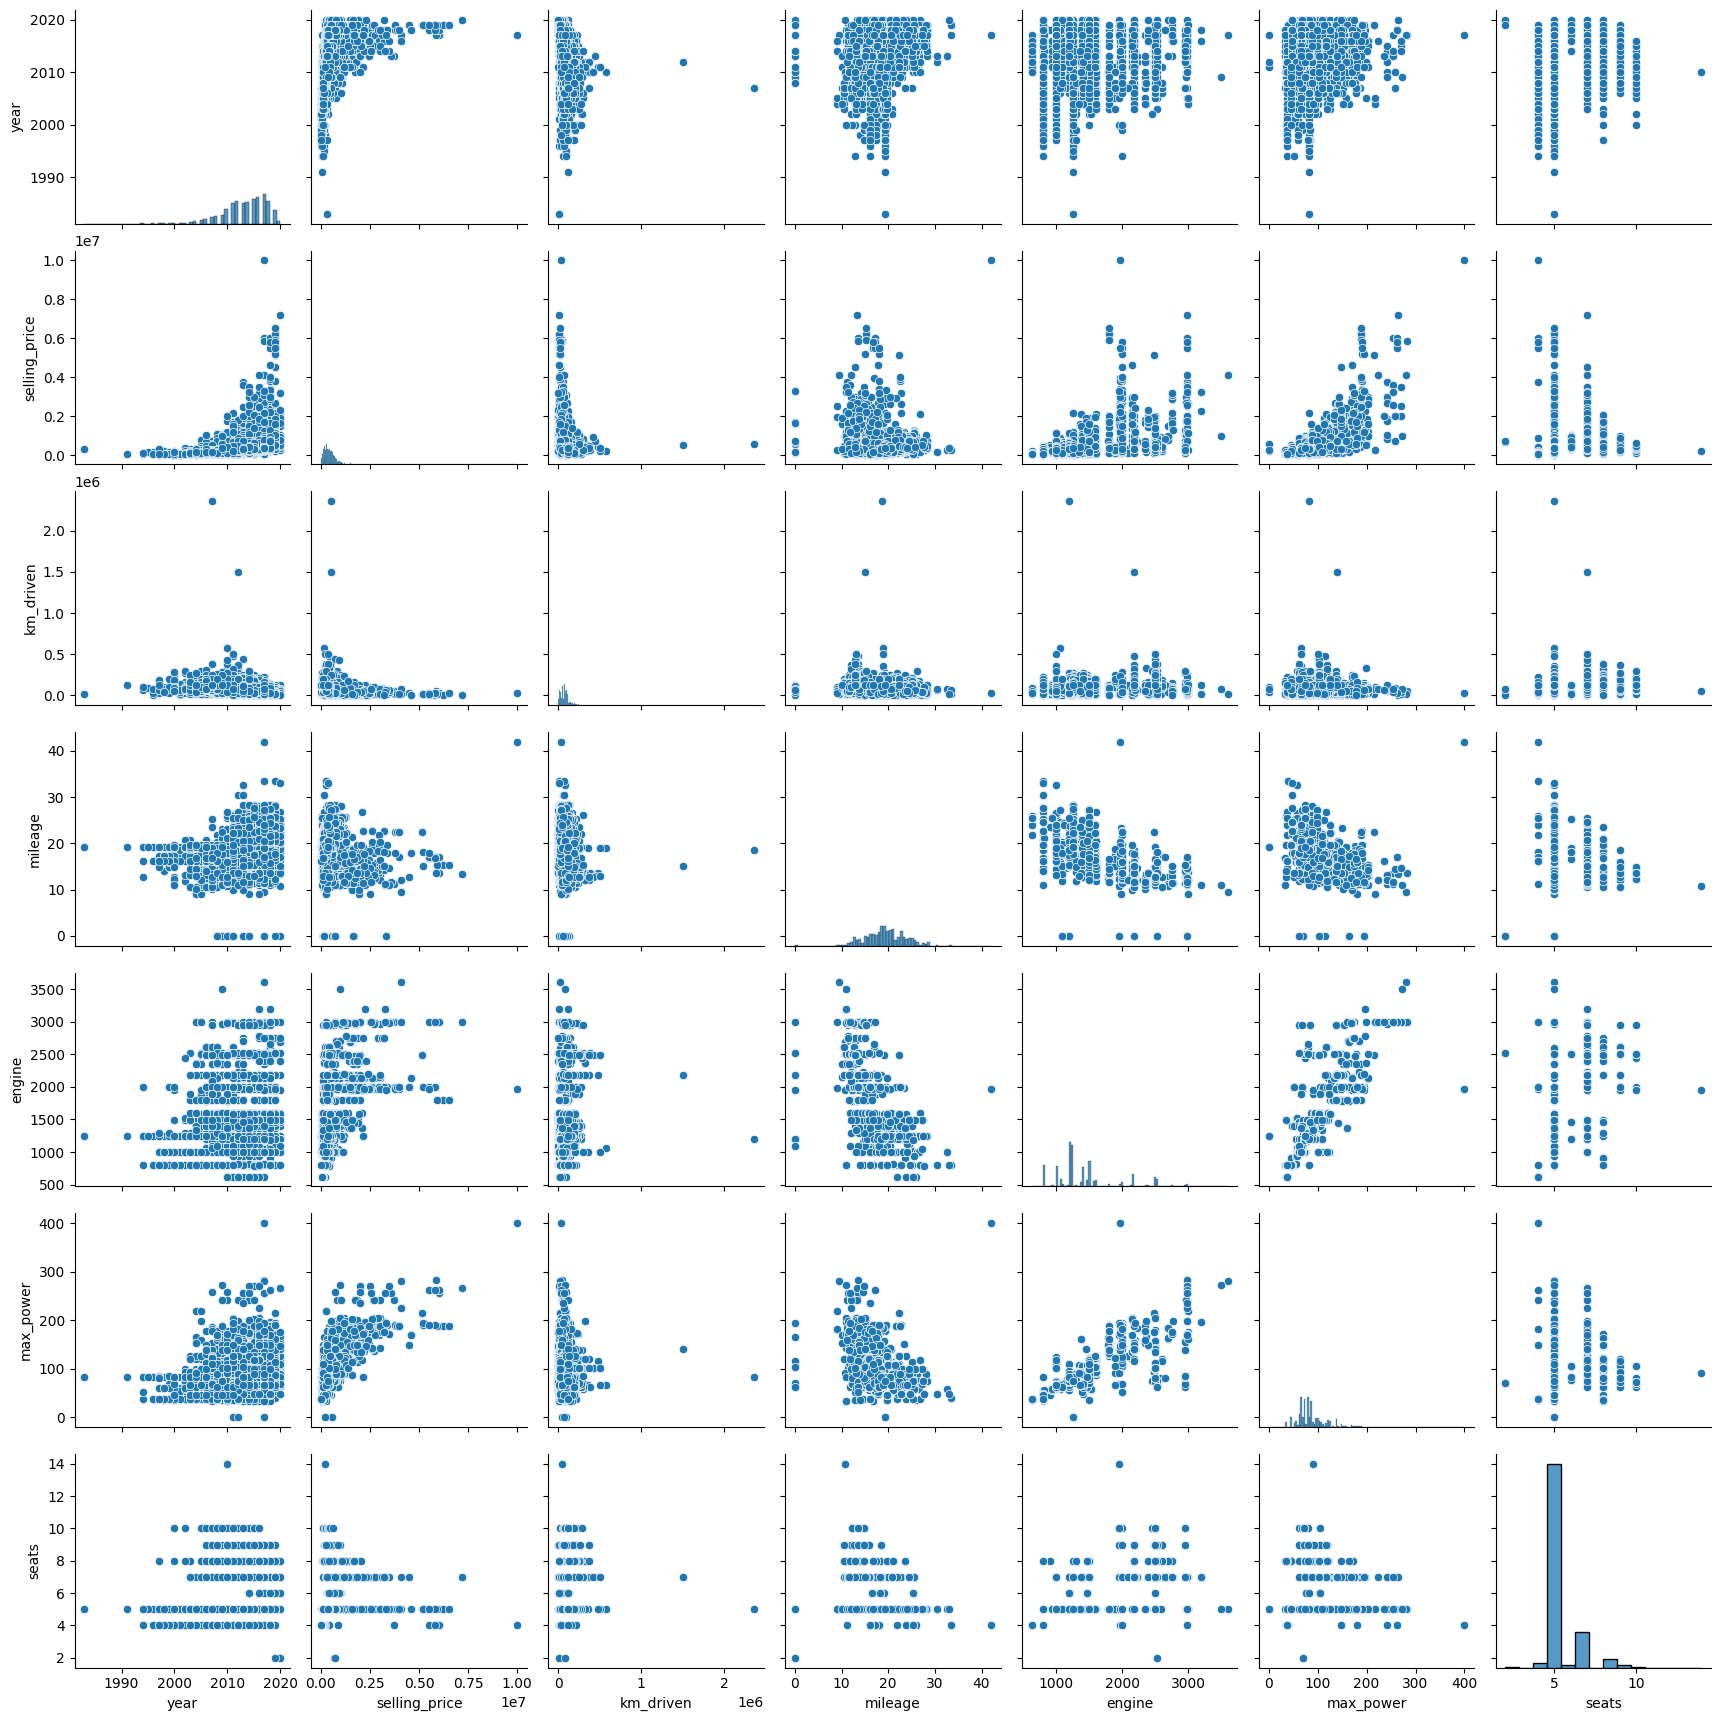

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

print("pairplot для трейна")
sns.pairplot(df_train)
plt.show()

pairplot для теста


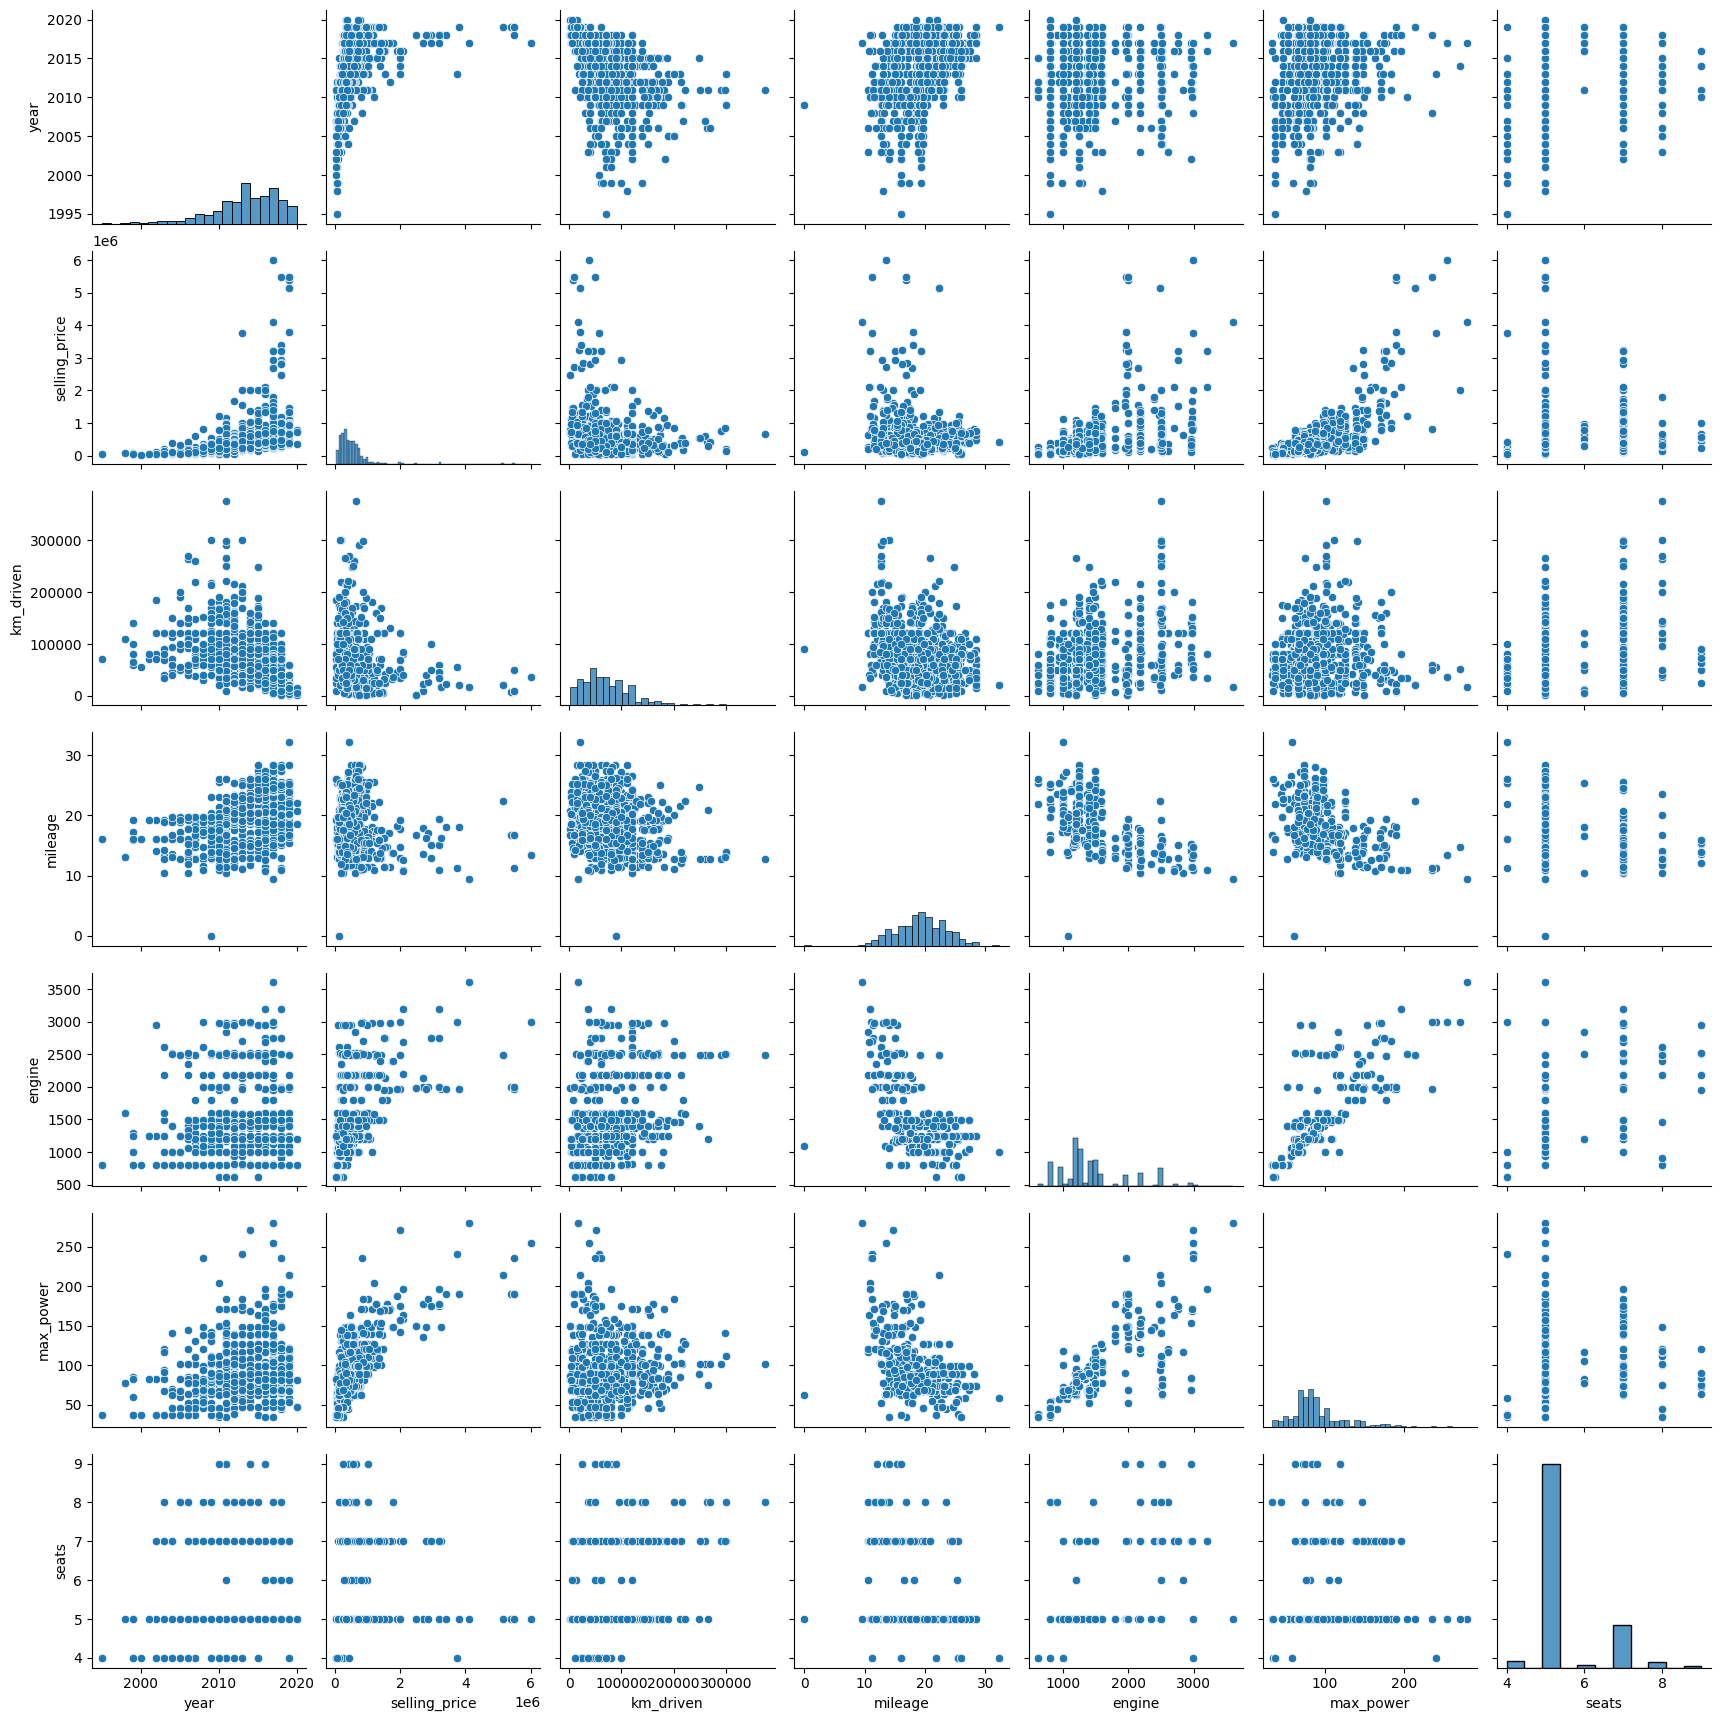

In [17]:
print("pairplot для теста")
sns.pairplot(df_test)
plt.show()

**Шаг 1. Анализ Train**

**Можно ли предположить связь признаков с целевой переменной?**
Да, связи отчетливо видны, если смотреть на строку или столбец `selling_price`:
*   **year vs selling_price:** Видна явная зависимость. Чем новее машина (больше год), тем выше цена. График похож на экспоненту.
*   **max_power vs selling_price:** Тоже сильная прямая связь. Чем мощнее машина, тем она дороже.
*   **km_driven vs selling_price:** Связь слабая, но она есть — чем больше пробег, тем, как правило, ниже цена (облако точек ползет вниз).

**Можно ли выдвинуть гипотезу о корреляциях признаков?**
Да, между самими признаками тоже есть зависимости:
*   **engine и max_power:** Очень сильная прямая корреляция. Больший объем двигателя почти всегда означает большую мощность (точки выстраиваются в диагональ).
*   **mileage и max_power/engine:** Обратная связь. Чем мощнее двигатель, тем меньше пробег на одном литре топлива (mileage падает).
*   **year и km_driven:** Чем машина новее, тем меньше у нее пробег, что логично.

**Шаг 2. Сравнение Train и Test**

**Похожими ли оказались совокупности при разделении на трейн и тест?**
Да, совокупности выглядят очень похожими.
*   Форма облаков рассеяния на обоих графиках достаточно похожа.
*   Гистограммы распределений (на диагоналях) тоже имеют одинаковую форму.
*   Единственное отличие — на трейне чуть больше редких выбросов (например, в цене или пробеге), но это нормально, так как тренировочная выборка просто больше по размеру.

**Вывод:** Данные разделены корректно, распределения по большей части совпадают.

### **Задание 7 (0.5 балла)**

И так, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)


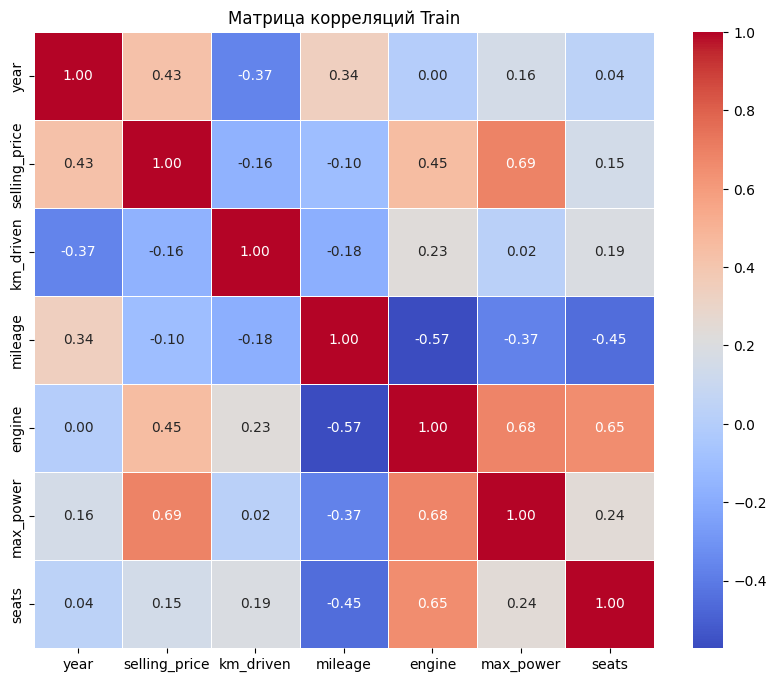

In [18]:
# 1. Считаем матрицу корреляций Пирсона
# numeric_only=True говорит пандасу игнорировать текстовые столбцы
corr_matrix = df_train.corr(numeric_only=True)

# 2. Настраиваем размер графика, чтобы цифры не слипались
plt.figure(figsize=(10, 8))

# 3. Рисуем тепловую карту
# annot=True пишет числа в ячейках
# cmap='coolwarm' делает понятные цвета от обратной к прямой корелляции от синего к красному соответственно
# fmt='.2f' оставляет 2 знака после запятой
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Матрица корреляций Train')
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

**1. Какие 2 признака наименее скоррелированы между собой?**

Самая слабая связь наблюдается между признаками `year` и `engine. Это значит, что зная только год выпуска, мы вообще ничего не можем сказать об объеме двигателя.
Также очень низкая корреляция между `km_driven` и `max_power`.

**2. Между какими наблюдается довольно сильная положительная линейная зависимость?**

Самый высокий коэффициент (**0.69**) у пары `selling_price` и `max_power`. Мощность сильнее всего влияет на цену.
Также сильная связь (**0.68**) между `engine` и `max_power`, что логично: чем больше двигатель, тем он мощнее.

**3. Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?**

**Да, правильно.**
Коэффициент корреляции между `year` и `km_driven` равен **-0.37**.
Отрицательное значение говорит об обратной связи: чем **выше** год (новее машина), тем **ниже** пробег. И наоборот: чем меньше год (старее машина), тем пробег больше.

### **Бонус (0.5 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их **и поясните.**

- Каждая дополнительная визуализация может принести до 0.25 баллов при условии, что она обоснована.

In [19]:
# your code here

# **Часть 2 | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.25 балла;

### **Задание 8 (0.05 балла)**

Сделайте тренировочный и тестовый наборы. Сделайте на тренировочный и тестовый наборы. Она уже даны, достаточно просто отделить целевой признак Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных. Используйте уже имеющиеся данные train и test при разбиении. Если считаете уместным применить какую-то более хитрую технику разбиения — примените, но опишите, зачем.

**Описание выбранных вещественных признаков:**

Я выбрал колонки `year`, `km_driven`, `mileage`, `engine`, `max_power` и `seats`.
Это все признаки, которые имеют числовой тип (`int` или `float`) и несут физический смысл (год, пробег, объем и т.д.).

In [20]:
# Составляем список признаков
# selling_price сюда не входит, так как это наш таргет
# torque мы удалили ранее
feature_cols = ['year', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']
# оставшиеся столбцы категориальные (object)

In [21]:
y_train = df_train['selling_price']
X_train = df_train[feature_cols]

In [22]:
y_test = df_test['selling_price']
X_test = df_test[feature_cols]

### **Задание 9 (0.2 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE

# 1. Создаем и обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Делаем предсказания для трейна и теста
pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

# 3. Считаем метрики
print("Метрики на Train:")
print(f"R2: {r2_score(y_train, pred_train):.4f}")
print(f"MSE: {MSE(y_train, pred_train):.0f}")

print("Метрики на Test:")
print(f"R2: {r2_score(y_test, pred_test):.4f}")
print(f"MSE: {MSE(y_test, pred_test):.0f}")

Метрики на Train:
R2: 0.5923
MSE: 116873067752
Метрики на Test:
R2: 0.5941
MSE: 233297548205


Вот выводы, основанные на полученных цифрах:

1.  **Качество модели ($R^2$):**
    Значение $R^2$ около **0.59** на обоих наборах данных. Это значит, что наша модель объясняет примерно **60%** разброса цен, используя только числовые признаки. Это средний результат: модель уловила основные зависимости, но до идеального предсказания еще далеко.

2.  **Переобучение:**
    Переобучения нет. Метрика $R^2$ на тесте (0.5941) практически совпадает с трейном (0.5923) и даже чуть-чуть выше. Это значит, что модель хорошо обобщает знания и не просто запомнила тренировочные примеры.

3.  **Странность с MSE:**
    MSE на тесте (233 млрд) почти в 2 раза больше, чем на трейне (116 млрд), хотя $R^2$ почти одинаковый.
    На мой взяглд, это объясняется природой данных: $R^2$ — это относительная метрика, а MSE — абсолютная. Видимо, в тестовой выборке сам разброс цен (дисперсия) выше, поэтому и ошибки в абсолютных деньгах получаются больше, хотя качество понимания данных у модели осталось прежним.

### **Задание 10 (0.15 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

In [24]:
from sklearn.preprocessing import StandardScaler

# 1. Создаем объект скалера
scaler = StandardScaler()

# 2. Обучаем его только на тренировочной выборке
scaler.fit(X_train)

# 3. Преобразуем данные
X_train_std = scaler.transform(X_train)
X_test_std = scaler.transform(X_test)

# Проверим результат (среднее должно быть около 0, стандартное отклонение 1)
print("Среднее первых признаков:", X_train_std.mean(axis=0)[:3])
print("Std первых признаков:    ", X_train_std.std(axis=0)[:3])

Среднее первых признаков: [ 2.32812247e-14 -6.20508211e-17  1.48435298e-16]
Std первых признаков:     [1. 1. 1.]


**Для себя**

 Метод `.fit()` мы вызываем только на X_train. Это нужно, чтобы мы не подглядывали в тестовые данные при расчете среднего и отклонения. Тестовые данные мы просто преобразуем `.transform()` с теми параметрами, которые выучили на трейне.

Если сделать `.fit()` на тесте, то произойдёт уточека данных

In [25]:
# 4. Обучаем модель заново на новых данных
model_std = LinearRegression()
model_std.fit(X_train_std, y_train)

# 5. Делаем предсказания
pred_train_std = model_std.predict(X_train_std)
pred_test_std = model_std.predict(X_test_std)

# 6. Считаем метрики
print("Метрики на Train (после стандартизации):")
print(f"R2: {r2_score(y_train, pred_train_std):.4f}")
print(f"MSE: {MSE(y_train, pred_train_std):.0f}")

print("\nМетрики на Test (после стандартизации):")
print(f"R2: {r2_score(y_test, pred_test_std):.4f}")
print(f"MSE: {MSE(y_test, pred_test_std):.0f}")

Метрики на Train (после стандартизации):
R2: 0.5923
MSE: 116873067752

Метрики на Test (после стандартизации):
R2: 0.5941
MSE: 233297548205


### **Задание 11 (0.1 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [26]:
# Создаем табличку: название признака и его вес
weights = pd.DataFrame({
    'feature': feature_cols,
    'weight': model_std.coef_
})

# Добавляем колонку с модулем веса, чтобы удобно сортировать
weights['abs_weight'] = weights['weight'].abs()

# Сортируем от самого важного к менее важному
display(weights.sort_values(by='abs_weight', ascending=False))

,feature,weight,abs_weight
4,max_power,322779.703236,322779.703236
0,year,152843.262358,152843.262358
3,engine,61176.857150,61176.857150
1,km_driven,-44148.047511,44148.047511
2,mileage,28781.086595,28781.086595
5,seats,-23220.570226,23220.570226


Судя по полученной таблице, самым информативным признаком оказался `max_power`.

У него самый большой вес. Это значит, что изменение мощности сильнее всего влияет на итоговое предсказание цены в нашей модели.

### **Задание 12 (0.25 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [27]:
from sklearn.linear_model import Lasso

# 1. Обучаем модель Lasso с параметрами по умолчанию (alpha=1.0)
# random_state фиксируем для воспроизводимости
lasso = Lasso(random_state=42)
lasso.fit(X_train_std, y_train)

# 2. Делаем предсказания
pred_train_lasso = lasso.predict(X_train_std)
pred_test_lasso = lasso.predict(X_test_std)

# 3. Выводим метрики
print("Метрики на Train (Lasso):")
print(f"R2: {r2_score(y_train, pred_train_lasso):.4f}")
print(f"MSE: {MSE(y_train, pred_train_lasso):.0f}")

print("\nМетрики на Test (Lasso):")
print(f"R2: {r2_score(y_test, pred_test_lasso):.4f}")
print(f"MSE: {MSE(y_test, pred_test_lasso):.0f}")

# 4. Смотрим на коэффициенты
weights_lasso = pd.DataFrame({
    'feature': feature_cols,
    'coef': lasso.coef_
})

print("\nВеса признаков после Lasso:")
display(weights_lasso)

# Проверяем, есть ли зануленные веса
zero_count = (weights_lasso['coef'] == 0).sum()
print(f"\nКоличество зануленных весов: {zero_count}")

Метрики на Train (Lasso):
R2: 0.5923
MSE: 116873067762

Метрики на Test (Lasso):
R2: 0.5941
MSE: 233298219171

Веса признаков после Lasso:


,feature,coef
0,year,152843.083853
1,km_driven,-44146.918538
2,mileage,28779.204085
3,engine,61172.025780
4,max_power,322780.586197
5,seats,-23217.693273



Количество зануленных весов: 0


**1. Оценка качества модели**

Качество модели **не изменилось**.
Метрики $R^2$ и MSE остались практически идентичными тем, что были у обычной линейной регрессии без регуляризации. Lasso с дефолтными настройками не дала прироста качества.

**2. Занулила ли регуляризация веса?**

**Нет, не занулила.**
Количество зануленных весов равно 0. Все признаки остались в модели.

**3. Почему так произошло?**

Считаю, что дело в **масштабе целевой переменной**.
Мы предсказываем цены в сотнях тысяч и миллионах, поэтому ошибка MSE получается очень большой. Lasso пытается минимизировать сумму: `Ошибка + alpha * Веса`. По умолчанию `alpha = 1`. Для модели этот штраф в 1 единицу — просто капля в море по сравнению с ошибкой в миллиарды. Модель просто не заметила регуляризацию, поэтому веса не обнулились и результат не изменился. Для работы Lasso здесь нужно подбирать гораздо более крупную `alpha`.

### **Задание 13 Финальный рывок (0.5 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию, описанную на семинарах.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [28]:
from sklearn.model_selection import GridSearchCV

# Задаем сетку параметров.
# Так как цены у нас в миллионах, alpha должна быть существенной, чтобы повлиять на веса.
# Попробуем значения от сотни до десятков тысяч.
param_grid = {'alpha': [100, 500, 1000, 5000, 10000, 15000, 20000]}

# Инициализируем поиск
# cv=10 — это 10 фолдов
lasso_grid = GridSearchCV(estimator=Lasso(random_state=42),
                          param_grid=param_grid,
                          cv=10,
                          scoring='neg_mean_squared_error') # минимизируем MSE

# Обучаем перебор на стандартизированных данных
lasso_grid.fit(X_train_std, y_train)

# Выводим результаты
print("Лучшие параметры:", lasso_grid.best_params_)
print()
# Достаем лучшую модель
best_lasso = lasso_grid.best_estimator_

# Предсказания
pred_train_best = best_lasso.predict(X_train_std)
pred_test_best = best_lasso.predict(X_test_std)

# Метрики
print("Метрики на Train (Lasso Tuned):")
print(f"R2: {r2_score(y_train, pred_train_best):.4f}")
print(f"MSE: {MSE(y_train, pred_train_best):.0f}")
print()
print("Метрики на Test (Lasso Tuned):")
print(f"R2: {r2_score(y_test, pred_test_best):.4f}")
print(f"MSE: {MSE(y_test, pred_test_best):.0f}")
print()
# Смотрим на веса
weights_best = pd.DataFrame({
    'feature': feature_cols,
    'coef': best_lasso.coef_
})

print("Веса лучшей модели:")
display(weights_best)

# Посчитаем, сколько моделей обучилось
# len(param_grid['alpha']) - количество вариантов параметров
# 10 - количество фолдов
n_models = len(param_grid['alpha']) * 10
print(f"Всего было обучено моделей: {n_models}")

Лучшие параметры: {'alpha': 1000}

Метрики на Train (Lasso Tuned):
R2: 0.5922
MSE: 116882918199

Метрики на Test (Lasso Tuned):
R2: 0.5930
MSE: 233976478967

Веса лучшей модели:


,feature,coef
0,year,152628.836894
1,km_driven,-43041.283085
2,mileage,26958.135423
3,engine,56434.958908
4,max_power,323638.478256
5,seats,-20363.465028


Всего было обучено моделей: 70


**1. Сколько грид-сёрчу пришлось обучать моделей?**

Всего было обучено **70 моделей**.
Это получилось, потому что мы указали сетку из 7 параметров `alpha` (от 100 до 20000) и использовали кросс-валидацию на 10 фолдов (7 * 10 = 70).

**2. Какой коэффициент регуляризации у лучшей из перебранных моделей?**

Лучший параметр **alpha = 1000**.

**3. Занулились ли какие-нибудь из весов при такой регуляризации?**
**Нет, не занулились.**

Если посмотреть на таблицу коэффициентов, все значения отличны от нуля (например, у `seats` вес около -20363, у `mileage` около 26958).

**Вывод:**

Несмотря на увеличение коэффициента регуляризации до 1000, этого все еще недостаточно, чтобы Lasso начала отбрасывать признаки. Поскольку цены на машины измеряются миллионами, веса модели очень большие, и штраф в 1000 для них незначителен. Качество модели ($R^2 \approx 0.59$) осталось на том же уровне, что и у обычной регрессии.

**Ваша задача 2:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [29]:
from sklearn.linear_model import ElasticNet

# Задаем сетку параметров
# alpha: сила регуляризации? берем похожие значения, что были в Lasso
# l1_ratio: 0 - это Ridge, 1 - это Lasso. Берем промежуточные значения.
param_grid_elastic = {
    'alpha': [100, 1000, 5000, 10000],
    'l1_ratio': [0.1, 0.5, 0.7, 0.9, 1.0]
}

# Инициализируем GridSearch
elastic_grid = GridSearchCV(estimator=ElasticNet(random_state=42),
                            param_grid=param_grid_elastic,
                            cv=10,
                            scoring='neg_mean_squared_error')

# Обучаем (это может занять немного времени, так как комбинаций больше)
elastic_grid.fit(X_train_std, y_train)

# Выводим лучшие параметры
print("Лучшие параметры:", elastic_grid.best_params_)

# Достаем лучшую модель
best_elastic = elastic_grid.best_estimator_

# Предсказания
pred_train_elastic = best_elastic.predict(X_train_std)
pred_test_elastic = best_elastic.predict(X_test_std)

# Метрики
print("\nМетрики на Train (ElasticNet Tuned):")
print(f"R2: {r2_score(y_train, pred_train_elastic):.4f}")
print(f"MSE: {MSE(y_train, pred_train_elastic):.0f}")

print("\nМетрики на Test (ElasticNet Tuned):")
print(f"R2: {r2_score(y_test, pred_test_elastic):.4f}")
print(f"MSE: {MSE(y_test, pred_test_elastic):.0f}")

# Считаем количество моделей
# Кол-во alpha * кол-во l1_ratio * кол-во фолдов
n_alphas = len(param_grid_elastic['alpha'])
n_ratios = len(param_grid_elastic['l1_ratio'])
cv_folds = 10
print(f"\nВсего было обучено моделей: {n_alphas * n_ratios * cv_folds}")

Лучшие параметры: {'alpha': 1000, 'l1_ratio': 1.0}

Метрики на Train (ElasticNet Tuned):
R2: 0.5922
MSE: 116882918199

Метрики на Test (ElasticNet Tuned):
R2: 0.5930
MSE: 233976478967

Всего было обучено моделей: 200


**1. Сколько грид-сёрчу пришлось обучать моделей?**

Грид-сёрч обучил **200 моделей**.
Это получилось из перемножения всех параметров: 4 варианта `alpha` * 5 вариантов `l1_ratio` * 10 фолдов кросс-валидации = 200.

**2. Какие гиперпараметры соответствуют лучшей из перебранных моделей?**

Лучшие параметры: **alpha = 1000** и **l1_ratio = 1.0**.

**Примечание:**

Так как `l1_ratio` равен **1.0**, наша ElasticNet превратилась в чистую Lasso-регрессию. Именно поэтому метрики ($R^2 \approx 0.59$) и лучший `alpha` (1000) полностью совпали с результатами предыдущего задания, где мы настраивали Lasso.

# **Часть 3| Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.75 основных балла и 0.25 бонусных.


**Задание 14 (0.1 балла)** Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

В этом домашнем задании мы предлагаем удалить его.

**Ваша задача:**
- [ ] Удалить столбец`name`

In [30]:
# Создаем X_train_cat и X_test_cat из исходных датафреймов
# Удаляем целевую переменную 'selling_price' и 'name'
cols_to_drop = ['selling_price', 'name']

X_train_cat = df_train.drop(cols_to_drop, axis=1)
X_test_cat = df_test.drop(cols_to_drop, axis=1)

В другом случае, конечно, мы могли бы предобработать данный столбец. В качестве бонуса предлагаем вам придумать и реализовать алгоритм предобработки.

**Бонус 0.25 балла**
- [ ] Предобработайте столбец `name`, чтобы избежать его удаления. Если предобработали столбец — можно закомментировать assert

In [31]:
assert X_train_cat.shape == (5840, 10)

In [32]:
X_train_cat.describe(include='object')

,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840
unique,4,3,2,5
top,Diesel,Individual,Manual,First Owner
freq,3177,5223,5336,3603


### **Задание 15 (0.4 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования. Обратите внимание, что во избежание мультиколлинеарности следует избавиться от одного из полученных столбцов при кодировании каждого признака методом OneHot.

In [33]:
from sklearn.preprocessing import OneHotEncoder # или можно использовать get_dummies из библиотеки pandas

# 1. Превращаем seats в строку, чтобы get_dummies считал его категорией
# Если этого не сделать, он останется числом и не закодируется
X_train_cat['seats'] = X_train_cat['seats'].astype(str)
X_test_cat['seats'] = X_test_cat['seats'].astype(str)

# 2. Список колонок для кодирования
# (остальные числовые колонки типа year, engine get_dummies оставит как есть)
cols_to_encode = ['fuel', 'seller_type', 'transmission', 'owner', 'seats']

# 3. Применяем OneHot Encoding
# drop_first=True — удаляет первый столбец из каждой категории
# dtype=int — чтобы получить 0 и 1 вместо True/False
X_train_ohe = pd.get_dummies(X_train_cat, columns=cols_to_encode, drop_first=True, dtype=int)
X_test_ohe = pd.get_dummies(X_test_cat, columns=cols_to_encode, drop_first=True, dtype=int)

# 4. Выравнивание столбцов
# Может возникнуть ситуация, когда в Train была категория (например, 14 мест), а в Test её нет.
# Тогда в тесте не создастся колонка "seats_14", и модель сломается из-за разного количества признаков.
# Команда reindex берет колонки из трейна и принудительно оставляет в тесте только их,
# а недостающие заполняет нулями.
train_cols = X_train_ohe.columns
X_test_ohe = X_test_ohe.reindex(columns=train_cols, fill_value=0)

# Проверяем размеры
print("Размерность трейна после OHE:", X_train_ohe.shape)
print("Размерность теста после OHE:", X_test_ohe.shape)

display(X_train_ohe.head())

Размерность трейна после OHE: (5840, 23)
Размерность теста после OHE: (1000, 23)


,year,km_driven,mileage,engine,max_power,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,...,owner_Test Drive Car,owner_Third Owner,seats_14,seats_2,seats_4,seats_5,seats_6,seats_7,seats_8,seats_9
0,2014,145500,23.40,1248,74.00,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
1,2014,120000,21.14,1498,103.52,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
2,2010,127000,23.00,1396,90.00,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,2007,120000,16.10,1298,88.20,0,0,1,1,0,...,0,0,0,0,0,1,0,0,0,0
4,2017,45000,20.14,1197,81.86,0,0,1,1,0,...,0,0,0,0,0,1,0,0,0,0


### **Задание 16 (0.25 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [34]:
from sklearn.linear_model import Ridge

# 1. Масштабируем данные (это обязательно для регуляризации)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_ohe)
X_test_sc = scaler.transform(X_test_ohe)

# 2. Задаем сетку параметров alpha
# Ridge обычно работает с меньшими коэффициентами, чем Lasso, но попробуем разные
param_grid = {'alpha': [0.1, 1, 10, 100, 1000, 5000]}

# 3. Настраиваем поиск
# scoring='r2' — максимизируем именно R2
ridge_grid = GridSearchCV(estimator=Ridge(random_state=42),
                          param_grid=param_grid,
                          cv=10,
                          scoring='r2')

# 4. Обучаем
ridge_grid.fit(X_train_sc, y_train)

# 5. Получаем лучшую модель и делаем предсказания
best_ridge = ridge_grid.best_estimator_

pred_train_ridge = best_ridge.predict(X_train_sc)
pred_test_ridge = best_ridge.predict(X_test_sc)

print("Лучшие параметры:", ridge_grid.best_params_)

# 6. Выводим метрики
print("\nМетрики на Train (Ridge + OHE):")
print(f"R2: {r2_score(y_train, pred_train_ridge):.4f}")
print(f"MSE: {MSE(y_train, pred_train_ridge):.0f}")

print("\nМетрики на Test (Ridge + OHE):")
print(f"R2: {r2_score(y_test, pred_test_ridge):.4f}")
print(f"MSE: {MSE(y_test, pred_test_ridge):.0f}")

Лучшие параметры: {'alpha': 1000}

Метрики на Train (Ridge + OHE):
R2: 0.6579
MSE: 98066768121

Метрики на Test (Ridge + OHE):
R2: 0.5989
MSE: 230577153852


### Ответ: Удалось ли улучшить качество прогнозов?

**Коротко:** На тренировочных данных — **да, значительно**. На тестовых — **почти нет**.

*   **Было (только числа):** $R^2$ Test $\approx 0.593$
* **Стало (с категориями):** $R^2$ Test $\approx 0.599$
    
Прирост на тесте совсем незначительный.

**Эффект переобучения:**

На **Train** качество выросло очень сильно: с $0.59$ до **$0.66$**.
Разрыв между трейном (0.66) и тестом (0.60) стал большим. Это говорит о том, что добавление категориальных признаков (через OneHotEncoding) сильно усложнило модель. Она начала запоминать особенности обучающей выборки, которые не работают на тестовой.

**Вывод:** Добавление категорий помогло модели лучше понять обучающие данные, но почти не помогло лучше предсказывать цены на новых машинах (тесте). Возможно, какие-то категории в тесте распределены иначе или их влияние нестабильно.

# **Часть 4. | Бизнесовая (0.5 балла)**

### **Задание 17 (0.5 балла)**

В мире бизнеса очень важно давать оценку качества модели понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какая лучше всего решает задачу бизнеса

In [35]:
def business_metric(y_true, y_pred):
    # 1. Считаем модуль разницы между фактом и прогнозом
    diff = np.abs(y_true - y_pred)

    # 2. Считаем порог - это 10% от реальной цены
    threshold = 0.10 * y_true

    # 3. Проверяем условие: ошибка <= 10%
    # Получаем массив True/False
    is_accurate = diff <= threshold

    # 4. Считаем долю True (среднее значение) и переводим в проценты
    return is_accurate.mean() * 100

print("Доля верных прогнозов (ошибка <= 10%):")

# 1. Обычная регрессия (на численных данных со стандартизацией)
metric_simple = business_metric(y_test, pred_test_std)
print(f"Linear Regression (Base): {metric_simple:.2f}%")

# 2. Lasso (после GridSearch)
metric_lasso = business_metric(y_test, pred_test_best)
print(f"Lasso Tuned: {metric_lasso:.2f}%")

# 3. ElasticNet
metric_elastic = business_metric(y_test, pred_test_elastic)
print(f"ElasticNet Tuned: {metric_elastic:.2f}%")

# 4. Ridge (с категориальными признаками OHE)
metric_ridge_ohe = business_metric(y_test, pred_test_ridge)
print(f"Ridge + OHE: {metric_ridge_ohe:.2f}%")

Доля верных прогнозов (ошибка <= 10%):
Linear Regression (Base): 22.70%
Lasso Tuned: 22.50%
ElasticNet Tuned: 22.50%
Ridge + OHE: 26.60%


Лучшей моделью для бизнеса оказалась **Ridge + OHE** (гребневая регрессия с категориальными признаками).

Добавление категорий позволило увеличить долю точных предсказаний почти на **4 процентных пункта**. Хотя общий $R^2$ на тесте вырос незначительно, для данной конкретной бизнес-метрики (попадание в 10% интервал) эта модель работает заметно лучше остальных.

In [36]:
import pickle

# 1. Собираем всё важное в один словарь
# - best_ridge: твоя лучшая обученная модель
# - scaler: обученный StandardScaler
# - medians: серия с медианами из задания 1
# - train_cols: список колонок после OHE (X_train_ohe.columns)

data_to_save = {
    'model': best_ridge,           # Лучшая модель (Ridge)
    'scaler': scaler,              # Обученный scaler
    'medians': medians,            # Медианы для заполнения пропусков
    'ohe_columns': X_train_ohe.columns.tolist() # Список колонок
}

# 2. Сохраняем в файл
with open('model_pack.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

# **<font color="green">Часть 5 | Создание интерактивного приложения на Streamlit (3 балла)</font>**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (1 балл)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (1 балл)
- Визуализировать веса обученной модели (1 балл)

# **Часть 6 | Оформление репозитория и оценка сервиса (3 балла)**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории. В этот же репозиторий позже будет добавлена вторая часть.

Под результатами первой части понимаем следующее:

---

### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

По результатам второй части, ждем:

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```

**И ссылку на приложение в StreamlitHub.**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.



### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном;
* слабая или неполная аналитика в `.md`-файле;
* беспорядок в ноутбуке или неясная логика вычислений;
* отсутствие возможности запустить Streamlit-приложение.